In [1]:
!python3 --version
!python3 -m pip install tensorflow pandas numpy scikit-learn matplotlib

Python 3.13.12
Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling1D
from keras.utils import to_categorical
from keras.optimizers import Adam

In [3]:
train = "final.csv"
test = "test.csv"

df = pd.read_csv(train)
test_df = pd.read_csv(test)

In [4]:
X = df.drop(columns=["label_tactic"]).values
y = df["label_tactic"].values

X_test = test_df.drop(columns=["label_tactic"]).values
y_test = test_df["label_tactic"].values

In [5]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

In [6]:
X = X.reshape(X.shape[0], X.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [7]:

def build_cnn(input_shape, num_classes):
    model = Sequential([
        
        Conv1D(64, kernel_size=3, padding="same", activation="relu", input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        
        Conv1D(128, kernel_size=3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        
        Conv1D(256, kernel_size=3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.4),

        # Replace Flatten with GAP
        GlobalAveragePooling1D(),

        # Dense head
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.03),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [8]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

fold_accuracies = []
histories = []

fold = 1
for train_idx, val_idx in skf.split(X, y_encoded):
    print(f"\nFold {fold}/10")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    y_train_cat = to_categorical(y_train, num_classes)
    y_val_cat = to_categorical(y_val, num_classes)

    model = build_cnn(
        input_shape=(X.shape[1], 1),
        num_classes=num_classes
    )

    history = model.fit(
        X_train,
        y_train_cat,
        epochs=75,
        batch_size=256,
        validation_data=(X_val, y_val_cat),
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)
    fold_accuracies.append(val_acc)
    histories.append(history)

    print(f"Fold {fold} Validation Accuracy: {val_acc:.4f}")
    fold += 1


Fold 1/10


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/75
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6894 - loss: 0.7744 - val_accuracy: 0.6361 - val_loss: 1.0979
Epoch 2/75
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7700 - loss: 0.5759 - val_accuracy: 0.6944 - val_loss: 0.6311
Epoch 3/75
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.7944 - loss: 0.5175 - val_accuracy: 0.8518 - val_loss: 0.4180
Epoch 4/75
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8054 - loss: 0.4942 - val_accuracy: 0.7774 - val_loss: 0.4957
Epoch 5/75
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8090 - loss: 0.4988 - val_accuracy: 0.8658 - val_loss: 0.3084
Epoch 6/75
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8064 - loss: 0.5118 - val_accuracy: 0.6679 - val_loss: 0.7890
Epoch 7/75
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8102 - loss: 0.5137 - val_accuracy: 0.7028 - val_loss: 0.6811
Epoch 8/75
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8034 - loss: 0.5328 - val_accu

In [9]:
print("\nCross-Validation Results")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Std Dev: {np.std(fold_accuracies):.4f}")


Cross-Validation Results
Mean Accuracy: 0.6084
Std Dev: 0.0746


In [10]:
y_cat = to_categorical(y_encoded, num_classes)

final_model = build_cnn(
    input_shape=(X.shape[1], 1),
    num_classes=num_classes
)

final_history = final_model.fit(
    X,
    y_cat,
    epochs=75,
    batch_size=256,
    verbose=1
)

Epoch 1/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6922 - loss: 0.7768
Epoch 2/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7849 - loss: 0.5396
Epoch 3/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8179 - loss: 0.4604
Epoch 4/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8194 - loss: 0.4559
Epoch 5/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8326 - loss: 0.4278
Epoch 6/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8403 - loss: 0.4229
Epoch 7/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8413 - loss: 0.4290
Epoch 8/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8499 - loss: 0.4023
Epoch 9/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8181 - loss: 0.4875
Epoch 10/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8292 - loss: 0.4660
Epoch 11/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8343 - loss: 0.4599
Epoch 12/75
469/469 ━━━━━━━━━━━━━━━━━━━━

In [11]:
y_test_cat = to_categorical(y_test_encoded, num_classes)

test_loss, test_acc = final_model.evaluate(X_test, y_test_cat, verbose=0)

print(f"\nBest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Best Accuracy: 0.9297
Test Loss: 0.3091


581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 1200x1200 with 0 Axes>

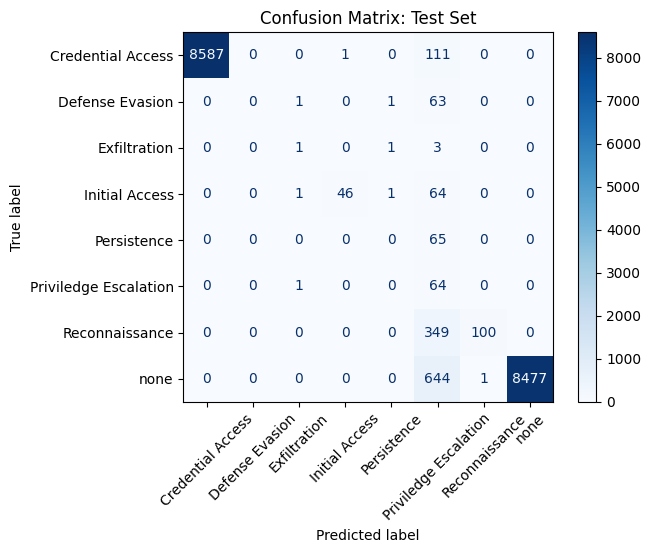

In [12]:
y_test_pred = np.argmax(final_model.predict(X_test), axis=1)

cm = confusion_matrix(y_test_encoded, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(12, 12))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix: Test Set")
plt.show()

581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report
                       precision    recall  f1-score   support

    Credential Access       1.00      0.99      0.99      8699
      Defense Evasion       0.00      0.00      0.00        65
         Exfiltration       0.25      0.20      0.22         5
       Initial Access       0.98      0.41      0.58       112
          Persistence       0.00      0.00      0.00        65
Priviledge Escalation       0.05      0.98      0.09        65
       Reconnaissance       0.99      0.22      0.36       449
                 none       1.00      0.93      0.96      9122

             accuracy                           0.93     18582
            macro avg       0.53      0.47      0.40     18582
         weighted avg       0.99      0.93      0.95     18582



C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

<Figure size 1200x1200 with 0 Axes>

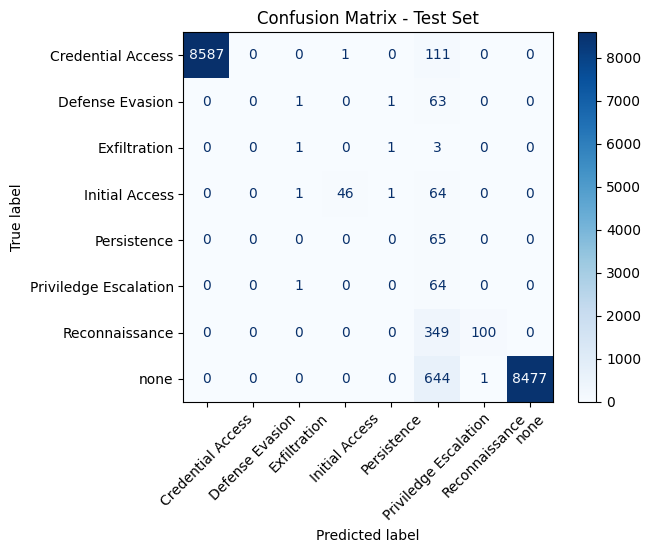


False Positive Rate (per class)
Credential Access: 0.0000
Defense Evasion: 0.0000
Exfiltration: 0.0002
Initial Access: 0.0001
Persistence: 0.0002
Priviledge Escalation: 0.0702
Reconnaissance: 0.0001
none: 0.0000

Average FPR: 0.008823068208443755


In [13]:

y_test_pred = np.argmax(final_model.predict(X_test), axis=1)


print("\nClassification Report")
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=label_encoder.classes_
    )
)


cm = confusion_matrix(y_test_encoded, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(12, 12))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.show()


print("\nFalse Positive Rate (per class)")

fpr_list = []

for i in range(len(cm)):
    FP = cm[:, i].sum() - cm[i, i]
    TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    
    fpr = FP / (FP + TN) if (FP + TN) != 0 else 0
    fpr_list.append(fpr)
    
    print(f"{label_encoder.classes_[i]}: {fpr:.4f}")

print("\nAverage FPR:", np.mean(fpr_list))

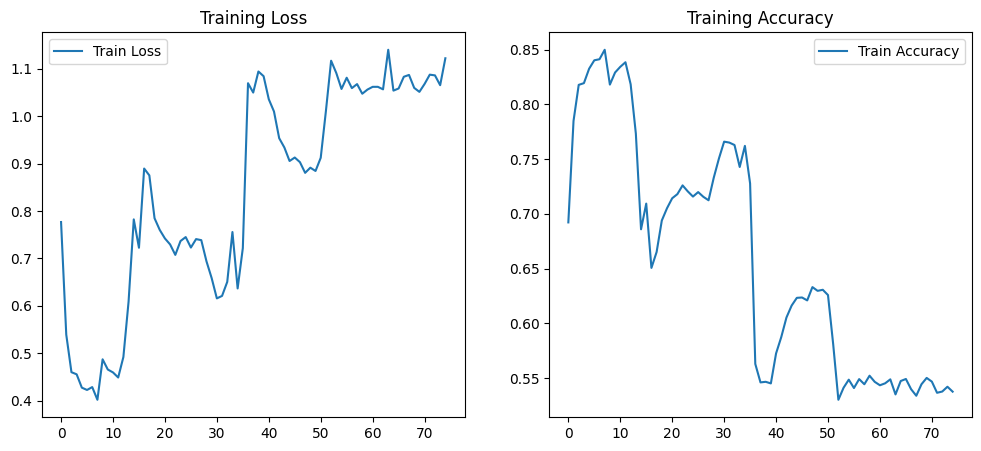

: 

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(final_history.history["loss"], label="Train Loss")
plt.title("Training Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(final_history.history["accuracy"], label="Train Accuracy")
plt.title("Training Accuracy")
plt.legend()

plt.show()